# CH8. 텍스트 분석


NLP(National Language Processing)와 텍스트 분석(Text Analyzing) 구분 방법

- NLP: 머신이 인간의 언어를 이해하고 해석하는 데 더 중점을 두고 기술이 발전
    
    : 언어를 해석하기 위한 기계 번역, 자동으로 질문을 해석하고 답을 해주는 질의응답 시스템 등의 영역에서 차별점 존재

- 텍스트 분석: 텍스트 마이닝이라고도 불리며 비정형 텍스트에서 의미 있는 정보를 추출하는 것에 좀 더 중점을 두고 있음
  
    : 머신러닝, 언어 이해, 통계 등을 활용해 모델을 수립하고 정부를 추출해 비즈니스 인텔리전스나 예측 분석 등의 분석 작업을 주로 수행


### 01. 텍스트 분석 이해

비정형 데이터인 텍스트를 분석하는 것

텍스트를 머신러닝에 적용하기 위해서는 비정형 텍스트 데이터를 어떻게 피처 형태로 추출하고 추출된 피처에 의미있는 값을 부여하는가 하는 것이 매우 중요한 요소이다.

텍스트를 word 기반의 다수의 피처로 추출하고 이 피처에 단어 빈도수와 같은 숫자 값을 부여하면 텍스트는 단어의 조합인 벡터값으로 표현될 수 있는데, 이렇게 텍스트를 변환하는 것을 **피처 벡터화** 또는 **피처 추출**이라고 한다.

**변환 방법**
1. BOW (Bag od Words)
2. Word2Vec

### 텍스트 분석 수행 프로세스
1. 텍스트 사전 준비 작업 (텍스트 전처리)
2. 피처 벡터화/추출
3. ML 모델 수립 및 학습/예측/평가

보통 NLTK/ Gensim/SpaCy와 같은 NLP전용 패키지와 함께 결합해 애플리케이션을 작성하는 경우가 많음

### 02. 텍스트 사전 준비 작업 (텍스트 전처리) - 텍스트 정규화


- 클렌징
  
   : 오히려 방해가 되는 불필요한 문자, 기호 등을 사전에 제거하는 작업 (HTML, XML태그나 특정 기호)


- 토큰화

  : 문서에서 문장을 분리하는 문장 토큰화와 문장에서 단어를 토큰으로 분리하는 단어 토큰화로 나눌 수 있음

In [1]:
from nltk import sent_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

text_sample = 'The Matrix is everywhere its all around us, here even in this room.\
              You can see it out your window or on your television.\
              You feel it when you go to work, or go to church or pay your taxes.'

sentences = sent_tokenize(text=text_sample)
print(type(sentences), len(sentences))
print(sentences)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<class 'list'> 3
['The Matrix is everywhere its all around us, here even in this room.', 'You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay your taxes.']


In [2]:
from nltk import word_tokenize

sentence = "The Matrix is everywhere its all around us, here even in this room."
words = word_tokenize(sentence)
print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


In [3]:
from nltk import word_tokenize, sent_tokenize

#여러 개의 문장으로 된 입력 데이터를 문장별로 단어 토큰화하게 만드는 함수 생성
def tokenize_text(text):

  #문장별로 분리 토큰
  sentences = sent_tokenize(text)
  #분리된 문장별 단어 토큰화
  word_tokens = [word_tokenize(sentence) for sentence in sentences]
  return word_tokens

#여러 문장들에 대해 문장별 단어 토큰화 수행
word_tokens = tokenize_text(text_sample)
print(type(word_tokens), len(word_tokens))
print(word_tokens)

<class 'list'> 3
[['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.'], ['You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'your', 'taxes', '.']]



- 필터링/ 스톱워드 제거/ 철자 수정


**스톱 워드 제거**
: 분석에 큰 의미가 없는 단어

언어별로 이러한 스톱워드가 목록화되어 있다. NLTK의 경우 가장 다양한 언어의 스톱워드를 제공한다.

In [4]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
print('영어 stop words 갯수:', len(nltk.corpus.stopwords.words('english')))
print(nltk.corpus.stopwords.words('english')[:20])

영어 stop words 갯수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [6]:
import nltk

stopwords = nltk.corpus.stopwords.words('english')
all_tokens = []
#위 예제에서 3개의 문장별로 얻은 word_tokens list에 대해 스톱 워드를 제거하는 반복문
for sentence in word_tokens:
  filtered_words = []
  #개별 문장별로 토큰화된 문장 list에 대해 스톱 워드를 제거하는 반복문
  for word in sentence:
    #소문자로 모두 변환
    word = word.lower()
    #토큰화된 개별 단어가 스톱 워드의 단어에 포함되지 않으면 word_tokens에 추가
    if word not in stopwords:
      filtered_words.append(word)
  all_tokens.append(filtered_words)

print(all_tokens)

[['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', '.'], ['see', 'window', 'television', '.'], ['feel', 'go', 'work', ',', 'go', 'church', 'pay', 'taxes', '.']]


- Stemming과 Lemmatization

문법적 또는 의미적으로 변화하는 단어의 원형을 찾는 것

두 기능 모두 원형 단어를 찾는다는 목적은 유사하나, Lemmatization이 Stemming보다 정교하며 의미론적인 기반에서 단어의 원형을 찾는다.

Stemming은 원형 단어로 변환 시 일반적인 방법을 적용하거나 더 단순화된 방법을 적용해 원래 다어에서 일부 철자가 훼손된 어근 단어를 추출하는 경향이 있다.


NLTK는 다양한 Stemmer와 Lemmatization를 제공
- Porter, Lancaster, Snowball Stemmer
- WordNetLemmatization

In [7]:
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

print(stemmer.stem('working'), stemmer.stem('works'), stemmer.stem('worked'))
print(stemmer.stem('amusing'), stemmer.stem('amuses'), stemmer.stem('amused'))
print(stemmer.stem('happier'), stemmer.stem('happiest'))
print(stemmer.stem('fancier'), stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


In [8]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemma = WordNetLemmatizer()
print(lemma.lemmatize('amusing', 'v'), lemma.lemmatize('amuses', 'v'), lemma.lemmatize('amused', 'v'))
print(lemma.lemmatize('happier', 'a'), lemma.lemmatize('happiest', 'a'))
print(lemma.lemmatize('fancier', 'a'), lemma.lemmatize('fanciest', 'a'))

[nltk_data] Downloading package wordnet to /root/nltk_data...


amuse amuse amuse
happy happy
fancy fancy


### Bag of Words - BOW

장점: 쉽고 빠른 구축

단점: 문맥 의미 반영 부족, 최소 행렬 문제

머신러닝 알고리즘은 일반적으로 숫자형 피처를 데이터로 입력받아 동작하기 때문에 텍스트와 같은 데이터는 머신러닝 알고리즘에 바로 입력할 수 없다. 따라서 텍스트는 특정 의미를 가지는 숫자형 값인 벡터값으로 변환해야 하는데 이를 **피처 벡터화**라고 한다.

BOW의 피처 벡터화는 두 가지 방식이 있다.

- 카운트 기반의 벡터화

  : 단어 피처에 값을 부여할 때 각 문서에서 해당 단어가 나타나는 횟수, 즉 Count를 부여하는 경우

- TF-IDF 기반의 벡터화

  : 카운트만 부여할 경우 언어의 특성상 문장에서 자주 사용될 수밖에 없는 단어까지 높은 값을 부여하게 되는 문제를 보완

  
  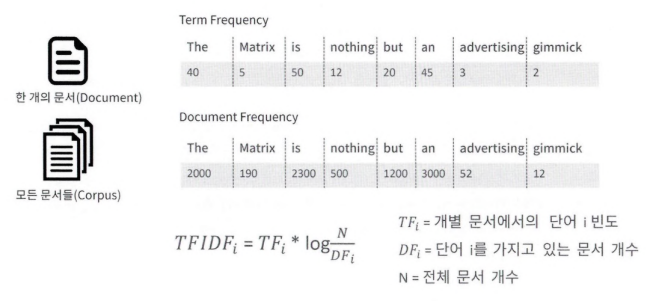

사이킷런의 Count 및 TF-IDF 벡터화 구현: CountVectorizer, TfidfVectorizer

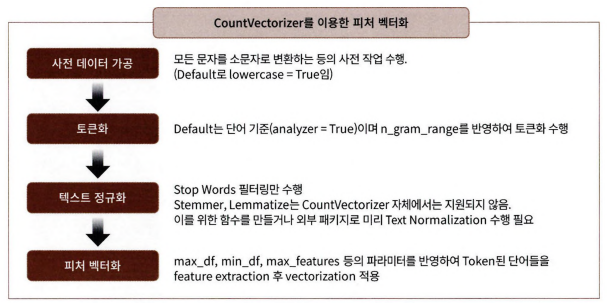

### BOW 벡터화를 위한 희소 행렬

사용자 입장에서 피처 벡터화된 희소 행렬이 어떤 형태인지 중요하지 않을 수 있지만, 더 난이도가 있는 ML 모델을 수립하기 위해서는 이러한 희소 행렬이 어떤 형태로 되어 있는지 알아야 한다.

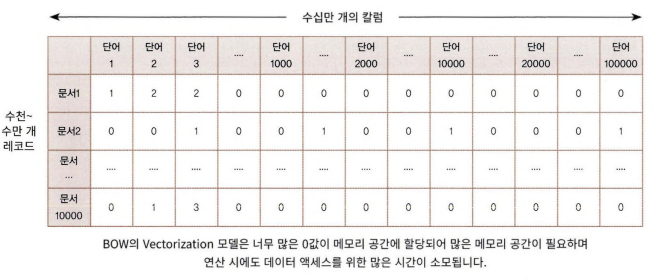

이 희소 행렬은 너무 많은 불필요한 0값이 메모리 공간에 할당되어 메모리 공간이 많이 필요하며, 행렬의 크기가 커서 연산 시에도 데이터 액세스 시산이 많이 소모된다. 따라서 이러한 희소 행렬을 물리적으로 적은 메모리 공간을 차지할 수 있도록 변환해야 한다.

대표적인 방법은 **COO형식**과 **CSR형식**이다.

- 희소행렬 COO 형식

In [10]:
import numpy as np

dense = np.array([[3,0,1],[0,2,0]])

In [11]:
from scipy import sparse

#0이 아닌 데이터 추출
data = np.array([3,1,2])

#행 위치와 열 위치를 각각 배열로 생성
row_pos = np.array([0,0,1])
col_pos = np.array([0,2,1])

#sparse 패키지의 coo_matrix를 이용해 COO형식으로 희소 행렬 생성
sparse_coo = sparse.coo_matrix((data,(row_pos,col_pos)))

In [12]:
sparse_coo.toarray()

array([[3, 0, 1],
       [0, 2, 0]])

- 희소 행렬  CSR 형식

Compressed Sparse Row의 약자이며 행 위치 배열 내에 있는 고유한 값의 시작 위치만 다시 별도의 위치 배열로 가지는 변환 방식을 의미한다.

In [13]:
[[0,0,1,0,0,5],
 [1,4,0,3,2,5],
 [0,6,0,3,0,0],
 [2,0,0,0,0,0],
 [0,0,0,7,0,8],
 [1,0,0,0,0,0]]

[[0, 0, 1, 0, 0, 5],
 [1, 4, 0, 3, 2, 5],
 [0, 6, 0, 3, 0, 0],
 [2, 0, 0, 0, 0, 0],
 [0, 0, 0, 7, 0, 8],
 [1, 0, 0, 0, 0, 0]]

In [14]:
from scipy import sparse

dense2 = np.array([[0,0,1,0,0,5],
                   [1,4,0,3,2,5],
                   [0,6,0,3,0,0],
                   [2,0,0,0,0,0],
                   [0,0,0,7,0,8],
                   [1,0,0,0,0,0]])

#0이 아닌 데이터 추출
data2 = np.array([1,5,1,4,3,2,5,6,3,2,7,8,1])

#행 위치와 열 위치를 각각 array로 생성
row_pos = np.array([0,0,1,1,1,1,1,2,2,3,4,4,5])
col_pos = np.array([2,5,0,1,3,4,5,1,3,0,3,5,0])

#COO형식으로 변환
sparse_coo = sparse.coo_matrix((data2,(row_pos, col_pos)))

#행 위치 배열의 고유한 값의 시작 위치 인덱스를 배열로 생성
row_pos_ind = np.array([0,2,7,9,10,12,13])

#CSR 형식으로 변환
sparse_csr = sparse.csr_matrix((data2, col_pos, row_pos_ind))

print('COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_coo.toarray())
print('CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_csr.toarray())

COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


In [15]:
dense3 = np.array([[0,0,1,0,0,5],
                   [1,4,0,3,2,5],
                   [0,6,0,3,0,0],
                   [2,0,0,0,0,0],
                   [0,0,0,7,0,8],
                   [1,0,0,0,0,0]])

coo = sparse.coo_matrix(dense3)
csr = sparse.csr_matrix(dense3)

사이킷런의 CountVectorizer나 TfidfVectorizer 클래스로 변환된 피처 벡터화 행렬은 모두 사이파이의 CSR형태의 희소 행렬이다.